In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

### Parameter Values

- $\alpha$: infection rate from living hosts
- $\beta$: death rate from disease
- $\gamma$: infection rate from deceased hosts
- $\delta$: death rate of fungus in dead hosts
- $\zeta$: vaccination rate (assume no recovery without vaccination)
- $\sigma$: amplitude of seasional variation in transmission
- $\eta$: rate at which vaccination loses efficacy

##### Other Notes

- The vaccination term pulls from the general population (susceptible and infected). It takes a proportion $\zeta$ of the surviving population. This is represented in the model by `zeta*I*(sum(y) - (V + R1 + R2))`.

In [2]:
def model_with_vaccine(t, y, params=[.09, .005, .001, .004, .001, .005]):
    S, I, V, R1, R2 = y
    alpha1, gamma, eta, zeta, beta, delta = params

    # introduce periodic seasonal transmission
    sigma = 6    # amplitude of seasonal variation in transmission
    alpha = alpha1*(1 + sigma*np.cos(2*np.pi*t))
    
    dy = [
        -alpha*I*S - gamma*I*R1 + eta*V - zeta*S*(sum(y) - (V + R1 + R2)),    # dS
        alpha*I*S + gamma*I*R1 - zeta*I*(sum(y) - (V + R1 + R2)) - beta*I,    # dI
        zeta*(I + S)*(sum(y) - (V + R1 + R2)) - eta*V,                        # dV
        beta*I - delta*R1,                             # dR1
        delta*R1                                       # dR2
    ]
    return dy

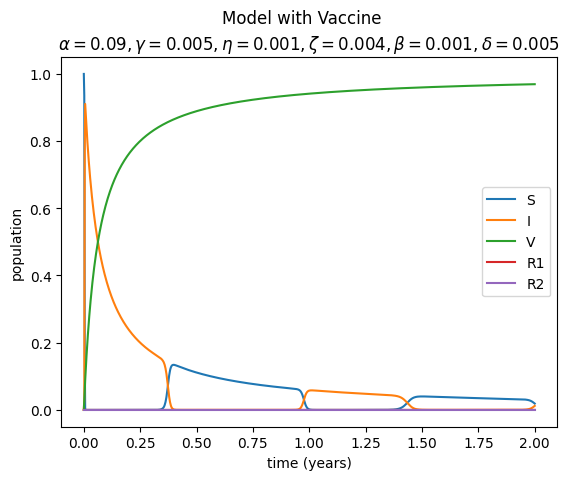

In [3]:
# define parameters for use with solve_ivp
initial = [4000, 1, 1, 0, 0]
alpha, gamma, eta, zeta, beta, delta = .09, .005, .001, .004, .001, .005
sol = solve_ivp(model_with_vaccine, t_span=[0, 2], y0=initial, t_eval=np.linspace(0, 2, 1000), args=[[alpha, gamma, eta, zeta, beta, delta]])
t_vals = np.linspace(0, 2, 1000)

# graph each compartment
plt.plot(sol.t, sol.y[0] / sum(initial), label='S')
plt.plot(sol.t, sol.y[1] / sum(initial), label="I")
plt.plot(sol.t, sol.y[2] / sum(initial), label="V")
plt.plot(sol.t, sol.y[3] / sum(initial), label="R1")
plt.plot(sol.t, sol.y[4] / sum(initial), label="R2")

# label the graph
plt.suptitle(fr"Model with Vaccine")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \eta = {eta}, \zeta = {zeta}, \beta = {beta}, \delta = {delta}$")
plt.xlabel("time (years)")
plt.ylabel("population")
plt.legend()
# plt.savefig("figures/ModelWithVaccine_take3.png")